# EquiHarmony vs torch_harmonics: Spherical Basis Comparison

This notebook compares spherical harmonics basis functions from:
- `eharmony.spherical_harmonics.SphericalHarmonics`
- `torch_harmonics.InverseRealSHT`

It includes both quantitative mode-by-mode similarity and visual checks.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from eharmony.spherical_harmonics import SphericalHarmonics
from torch_harmonics import InverseRealSHT

# Configuration
L = 4  # max degree in EquiHarmony (inclusive)
nlat = 180
nlon = 180

# Use deterministic seeds for repeatability
np.random.seed(0)
torch.manual_seed(0)

In [2]:
# --- EquiHarmony basis ---
eq = SphericalHarmonics(L, grid_type="linear", num_theta=nlat, num_phi=nlon)
eq_basis = eq.Y.detach().cpu().numpy()  # [mode, theta, phi]

# --- torch_harmonics basis via inverse transform of one-hot coefficients ---
# lmax and mmax are exclusive upper bounds in torch_harmonics, so use L+1
lmax = mmax = L + 1
nmodes = lmax * lmax
isht = InverseRealSHT(nlat, nlon, lmax=lmax, mmax=mmax)

e = torch.zeros(nmodes, lmax, mmax, dtype=torch.complex64)
midx = lambda l, m: l * (l + 1) + m
for l in range(lmax):
    for m in range(-l, l + 1):
        e[midx(l, m), l, abs(m)] = 1.0 if m >= 0 else 1.0j

th_basis = isht(e).detach().cpu().numpy()  # [mode, lat, lon]

assert eq_basis.shape == th_basis.shape, (eq_basis.shape, th_basis.shape)

def cosine_similarity(a, b):
    a = a.reshape(-1)
    b = b.reshape(-1)
    a = a - a.mean()
    b = b - b.mean()
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom == 0:
        return 0.0
    return float(np.dot(a, b) / denom)

transforms = {
    "identity": lambda x: x,
    "flip_lat": lambda x: x[::-1, :],
    "flip_lon": lambda x: x[:, ::-1],
    "flip_both": lambda x: x[::-1, ::-1],
}

rows = []
for i in range(nmodes):
    best_name = None
    best_corr = None
    for name, fn in transforms.items():
        c = cosine_similarity(eq_basis[i], fn(th_basis[i]))
        if best_corr is None or abs(c) > abs(best_corr):
            best_corr = c
            best_name = name
    rows.append((i, best_name, best_corr))

print(f"basis shape: {eq_basis.shape}")
print("first 10 modes (idx, best_transform, corr):")
for r in rows[:10]:
    print(r)

abs_corrs = np.array([abs(r[2]) for r in rows])
print("\nsummary:")
print("min |corr|:", abs_corrs.min())
print("median |corr|:", np.median(abs_corrs))
print("mean |corr|:", abs_corrs.mean())

basis shape: (25, 180, 180)
first 10 modes (idx, best_transform, corr):
(0, 'identity', 1.0)
(1, 'identity', -1.0000001192092896)
(2, 'identity', 1.0)
(3, 'identity', 1.0000001192092896)
(4, 'identity', -0.9999997019767761)
(5, 'identity', -0.9999994039535522)
(6, 'identity', 1.0)
(7, 'identity', 0.9999994039535522)
(8, 'identity', 0.9999998807907104)
(9, 'identity', -0.9999995827674866)

summary:
min |corr|: 0.9999992847442627
median |corr|: 1.0
mean |corr|: 0.9999998998641968


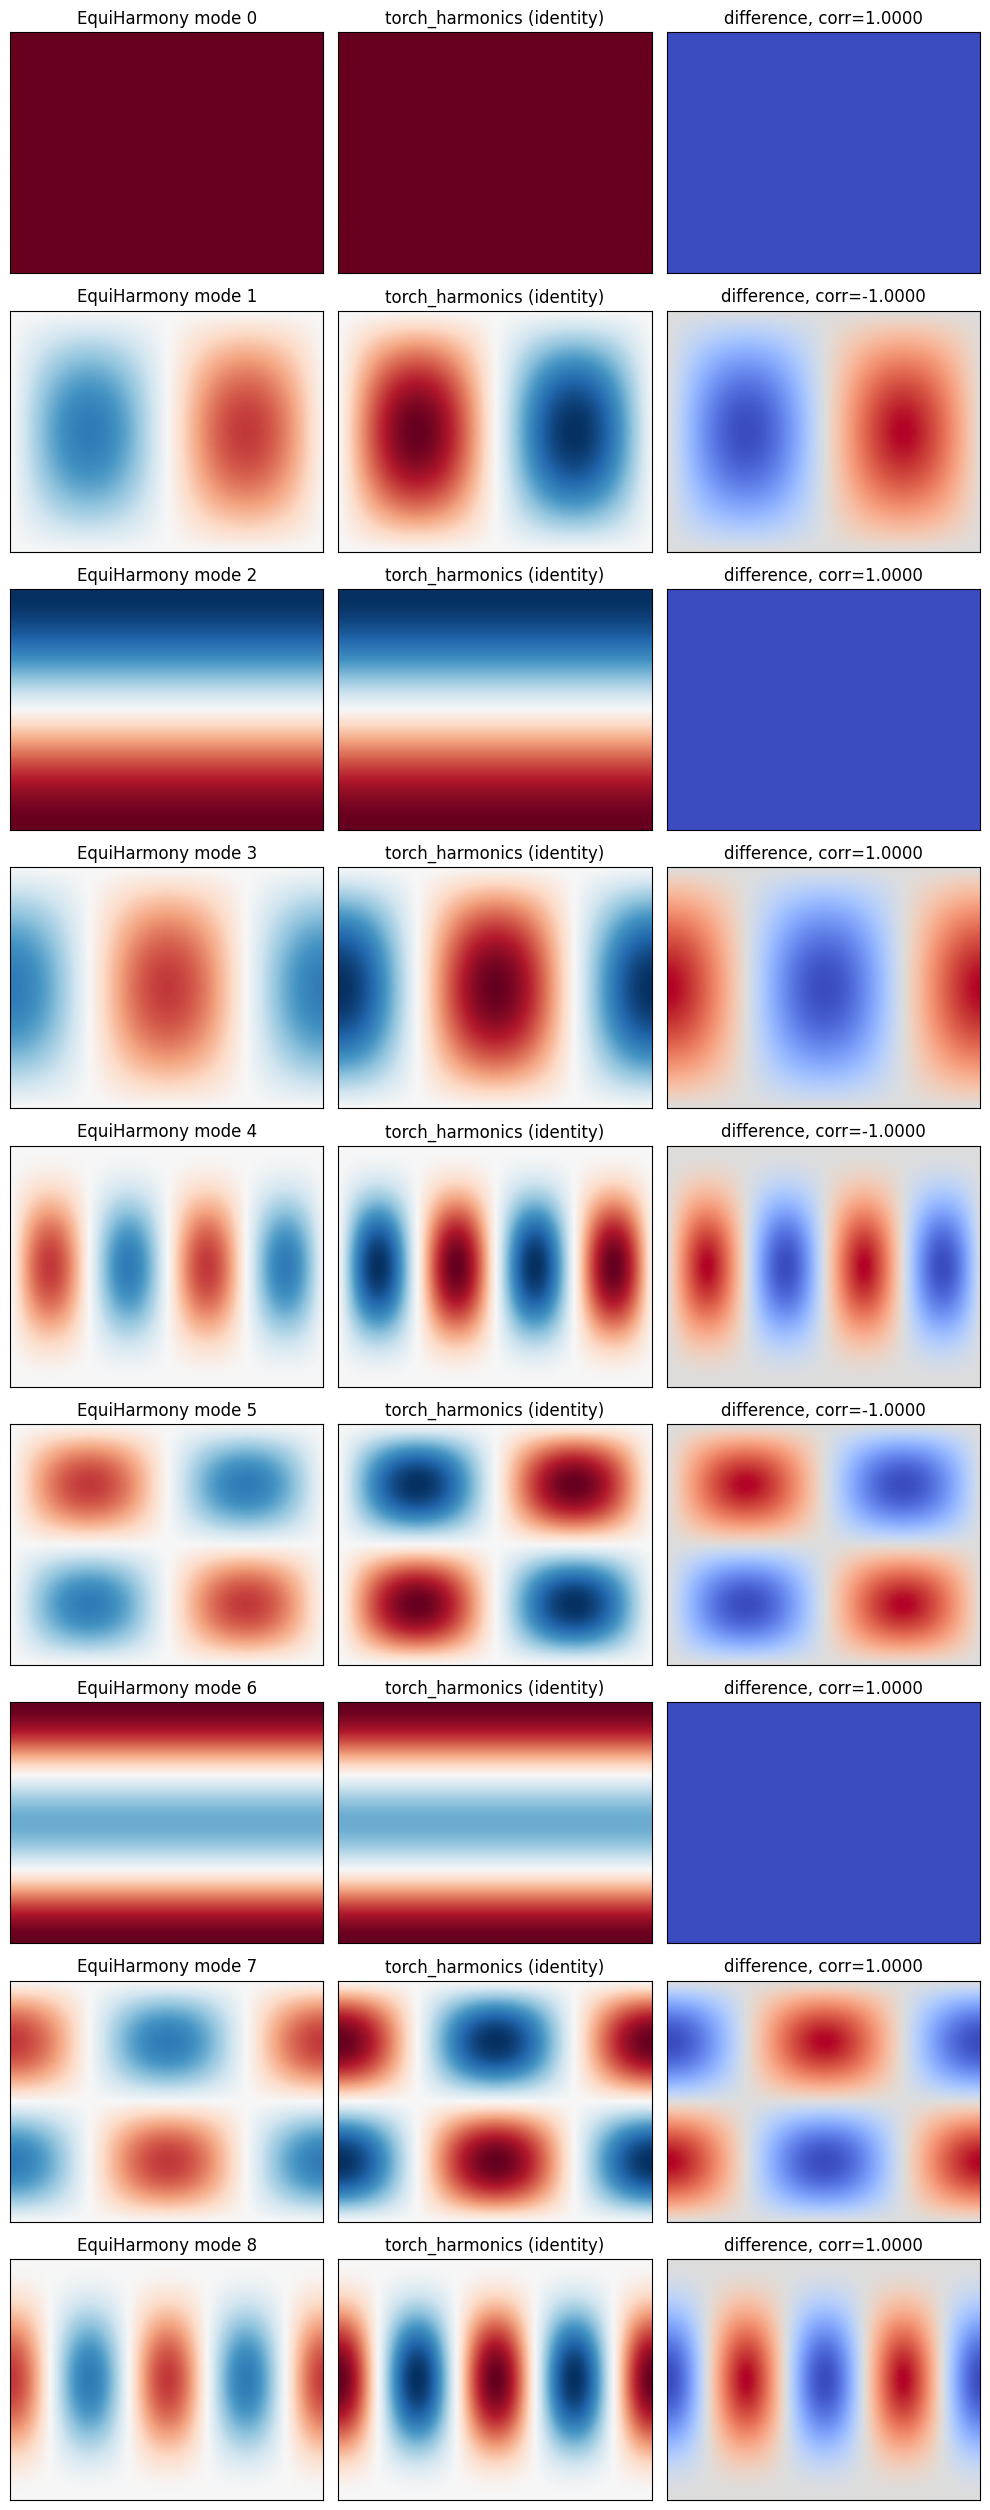

In [3]:
# Visual comparison for selected modes
selected = [0, 1, 2, 3, 4, 5, 6, 7, 8]

fig, axes = plt.subplots(len(selected), 3, figsize=(10, 2.8 * len(selected)))
if len(selected) == 1:
    axes = axes[None, :]

for row_idx, mode_idx in enumerate(selected):
    # Find best transform for this mode
    best_name = None
    best_corr = None
    best_data = None
    for name, fn in transforms.items():
        cand = fn(th_basis[mode_idx])
        c = cosine_similarity(eq_basis[mode_idx], cand)
        if best_corr is None or abs(c) > abs(best_corr):
            best_corr = c
            best_name = name
            best_data = cand

    v = max(np.abs(eq_basis[mode_idx]).max(), np.abs(best_data).max())

    axes[row_idx, 0].imshow(eq_basis[mode_idx], cmap="RdBu_r", vmin=-v, vmax=v, origin="lower", aspect="auto")
    axes[row_idx, 0].set_title(f"EquiHarmony mode {mode_idx}")

    axes[row_idx, 1].imshow(best_data, cmap="RdBu_r", vmin=-v, vmax=v, origin="lower", aspect="auto")
    axes[row_idx, 1].set_title(f"torch_harmonics ({best_name})")

    diff = eq_basis[mode_idx] - best_data
    d = np.abs(diff).max()
    axes[row_idx, 2].imshow(diff, cmap="coolwarm", vmin=-d, vmax=d, origin="lower", aspect="auto")
    axes[row_idx, 2].set_title(f"difference, corr={best_corr:.4f}")

    for c in range(3):
        axes[row_idx, c].set_xticks([])
        axes[row_idx, c].set_yticks([])

plt.tight_layout()
plt.show()

## Notes

- If most correlations are close to 1 in magnitude, the bases are equivalent up to sign and/or axis orientation.
- If correlations are low across all modes, check normalization conventions and angle conventions (`theta` colatitude vs latitude).